In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784',as_frame = False)

In [ ]:
X,y = mnist.data,mnist.target
print(X)
print(X.shape)
print(" - - - - - - - - - - - - - ")
print(y)
print(y.shape)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
(70000, 784)
 - - - - - - - - - - - - - 
['5' '0' '4' ... '4' '5' '6']
(70000,)


In [ ]:
import matplotlib.pyplot as plt
def plot(image_data):
  image = image_data.reshape(28,28)
  plt.imshow(image,cmap = "binary")
  plt.axis("off")

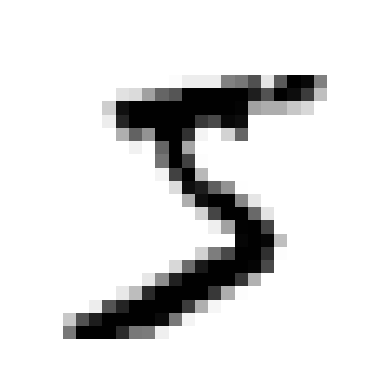

In [ ]:
plot(X[0])

In [ ]:
X_train,X_test,y_train,y_test = X[:60000] , X[60000:] ,y[:60000],y[60000:]

# 訓練二元分類器

In [ ]:
from sklearn.linear_model import SGDClassifier

y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

sgd_clf = SGDClassifier(random_state = 42)
sgd_clf.fit(X_train,y_train_5)

SGDClassifier(random_state=42)

In [ ]:
sgd_clf.predict([X[0]])

array([ True])

# 效能指標

**交叉驗證**


---



In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf,X_train,y_train,cv =3,scoring = "accuracy")

array([0.87365, 0.85835, 0.8689 ])

In [ ]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train,y_train)
print(any(dummy_clf.predict(X_train)))
cross_val_score(dummy_clf,X_train,y_train,cv =3,scoring = "accuracy")

True


array([0.11235, 0.11235, 0.1124 ])

**使用混淆矩陣來針對分類器做評估**


---

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd_clf,X_train,y_train_5,cv =3)
cm = confusion_matrix(y_train_5,y_train_pred)
print(cm)

[[53892   687]
 [ 1891  3530]]


In [ ]:
from sklearn.metrics import precision_score,recall_score,f1_score
print(precision_score(y_train_5,y_train_pred))
print(recall_score(y_train_5,y_train_pred))

0.8370879772350012
0.6511713705958311


In [ ]:
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_pred)

0.7325171197343847

 **Presicion Recall 取捨**


---



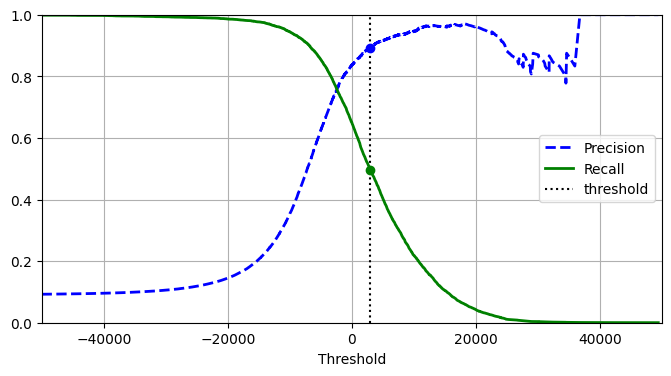

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
score = cross_val_predict(sgd_clf,X_train,y_train_5,cv =3,method = "decision_function")#用決策函數為每一個實例，生成一個分數。
precisions,recalls,thresholds = precision_recall_curve(y_train_5,score)#針對每一個閥值，生成對應的 p 、r 、t。


##獲得Precision Recall 取線
threshold = 3000
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies Figure 3–5
idx = (thresholds >= threshold).argmax()
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")

plt.show()

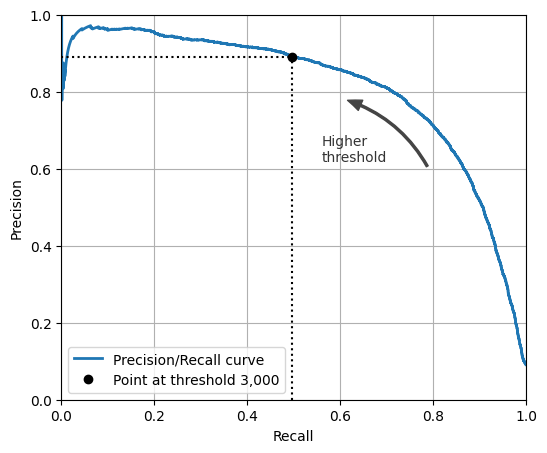

In [ ]:
import matplotlib.patches as patches  # extra code – for the curved arrow

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# extra code – just beautifies Figure 3–6
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

找precision為0.9的最低threshold，透過這兩種形式去找

**ROC曲線**


---



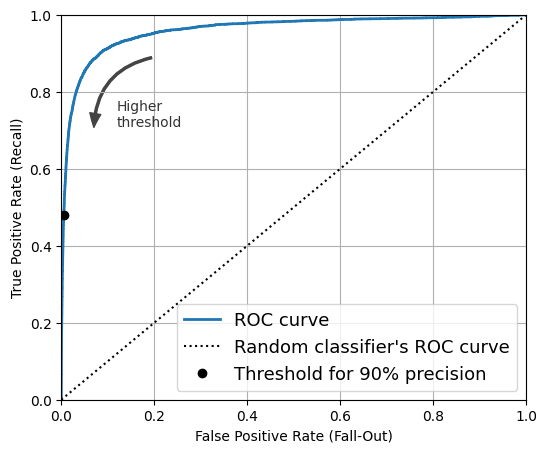

In [ ]:
#使用roc_curve函數去為每一個閥值對應的recall跟TNR

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, roc_curve
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# 1. 重新計算評分與 PR 曲線需要的變數，確保長度一致
score = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")
precisions, recalls, thresholds_pr = precision_recall_curve(y_train_5, score)

# 2. 獲取 ROC 曲線數據
fpr, tpr, thresholds_roc = roc_curve(y_train_5, score)

# 3. 找出精確度達到 90% 的最低閥值
# 注意：thresholds_pr 比 precisions 少一個元素
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds_pr[idx_for_90_precision]

# 4. 在 ROC 數據中找出最接近該閥值的索引
idx_for_threshold_at_90 = (thresholds_roc <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

# 畫圖
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# 美化圖表
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)

plt.show()

# 多類別分類

In [ ]:
from sklearn.svm import SVC
svm_slf = SVC(random_state = 42)
svm_slf.fit(X_train[:2000],y_train[:2000])
svm_slf.predict(X_train[:1])

array(['5'], dtype=object)